# 06 · Uncertainty I — MC Dropout

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/06_mc_dropout.ipynb)

Cheapest UQ: train one surrogate with dropout, then sample at test time with dropout *on*. Spread across stochastic forward passes estimates predictive uncertainty.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate)
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog); norm = Normalizer.fit(X)
net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, dropout=0.1, seed=0))
train_surrogate(net, X, Y, norm, epochs=2500, lr=2e-3)


[54.96309280395508,
 53.964847564697266,
 52.93754577636719,
 51.72032165527344,
 50.0558967590332,
 48.07881546020508,
 45.514251708984375,
 42.52755355834961,
 39.04070281982422,
 34.783966064453125,
 29.951387405395508,
 25.373313903808594,
 21.59075927734375,
 19.185636520385742,
 18.661849975585938,
 20.946481704711914,
 21.82553482055664,
 19.296655654907227,
 15.572507858276367,
 13.7689208984375,
 11.381414413452148,
 10.765926361083984,
 10.205435752868652,
 10.146112442016602,
 9.008378028869629,
 8.206352233886719,
 7.550334930419922,
 7.075494289398193,
 5.628407955169678,
 4.658382415771484,
 3.784554958343506,
 3.479393482208252,
 2.6576666831970215,
 2.749821901321411,
 2.6168479919433594,
 2.3891189098358154,
 2.352208375930786,
 2.169157028198242,
 1.7332707643508911,
 1.1384698152542114,
 1.2104859352111816,
 1.1640862226486206,
 1.1102484464645386,
 1.062087059020996,
 0.9893905520439148,
 1.1299009323120117,
 1.0886915922164917,
 0.7687247395515442,
 0.9034787416458

## Test-time dropout sampling

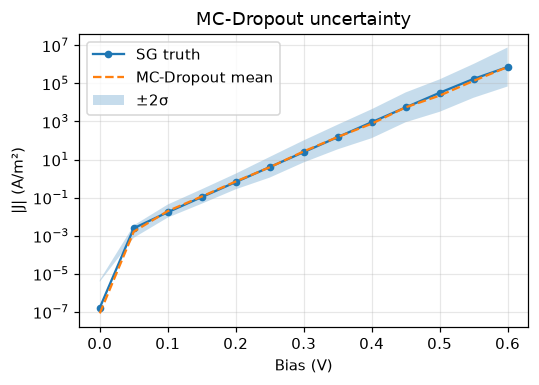

mean symlog σ = 0.317


In [3]:

def mc_predict(net, latent, biases, T=50):
    net.train()  # keep dropout active
    from bayespinn_inv.surrogate import make_features
    feats = np.stack([make_features(latent, b) for b in biases/VT])
    xb = norm(torch.tensor(feats, dtype=torch.float32))
    with torch.no_grad():
        S = np.stack([net(xb).numpy().ravel() for _ in range(T)])
    return S.mean(0), S.std(0)

C = step(1.7e21); lat = scaling.doping_to_net_input(C)
m_s, sd_s = mc_predict(net, lat, biases, T=100)
mean_I = symlog.inverse(m_s)
lo = symlog.inverse(m_s-2*sd_s); hi = symlog.inverse(m_s+2*sd_s)
Isg = sg_iv(C, biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases, np.abs(Isg), "o-", label="SG truth", ms=4)
plt.semilogy(biases, np.abs(mean_I), "--", label="MC-Dropout mean")
plt.fill_between(biases, np.abs(lo), np.abs(hi), alpha=0.25, label="±2σ")
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("MC-Dropout uncertainty"); plt.tight_layout(); plt.show()
print(f"mean symlog σ = {sd_s.mean():.3f}")
